rnn模型：model:type: 'ggeur_rnn'
python federatedscope/main.py --cfg scripts/example_configs/ggeur_rnn_sentiment.yaml
exp\ggeur_rnn_sentiment\ggeur_cpsd_lstm\sub_exp_20260121144900\exp_print.log
python federatedscope/main.py --cfg scripts/example_configs/fedavg_rnn_sentiment.yaml
exp\fedavg_rnn_sentiment\fedavg_cpsd_lstm_no_augmentation\sub_exp_20260126112305\exp_print.log

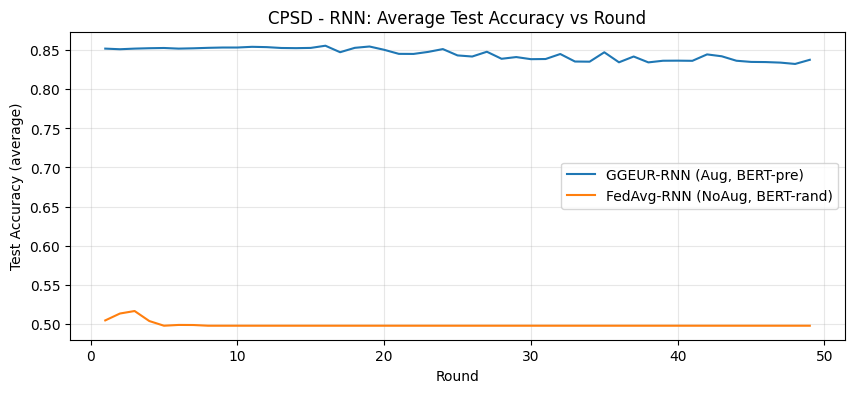

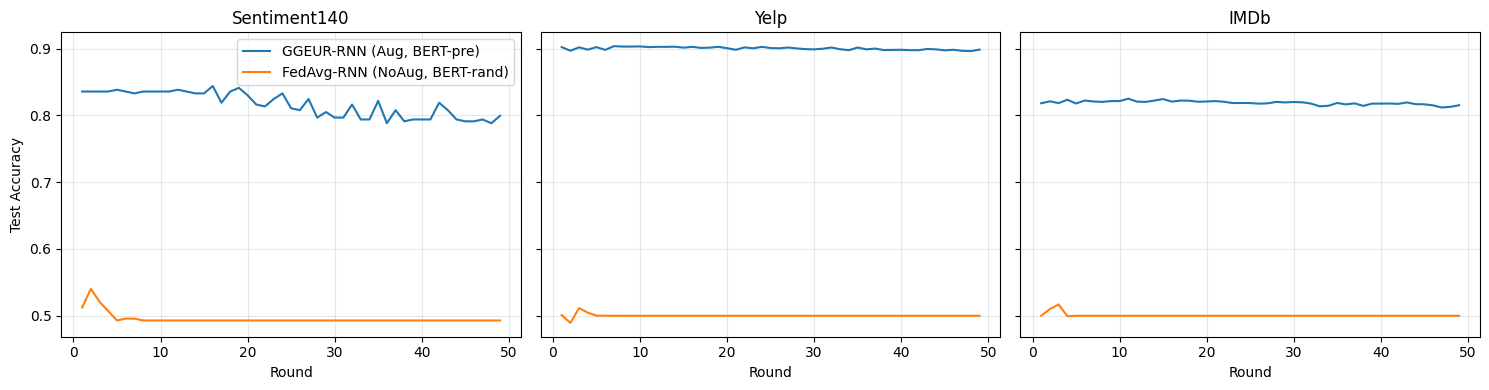

In [4]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/ggeur_rnn_sentiment/ggeur_cpsd_lstm/sub_exp_20260121144900/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_cpsd_lstm_no_augmentation/sub_exp_20260126112305/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "GGEUR-RNN (Aug, BERT-pre)": LOG_GGEUR_RNN,
    "FedAvg-RNN (NoAug, BERT-rand)": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - RNN: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["Sentiment140", "Yelp", "IMDb"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


lstm模型：model:type: 'ggeur_lstm'
python federatedscope/main.py --cfg scripts/example_configs/ggeur_rnn_sentiment.yaml
exp\ggeur_rnn_sentiment\ggeur_cpsd_lstm\sub_exp_20260120172157\exp_print.log
python federatedscope/main.py --cfg scripts/example_configs/fedavg_rnn_sentiment.yaml
exp\fedavg_rnn_sentiment\fedavg_cpsd_lstm_no_augmentation\sub_exp_20260121113120\exp_print.log

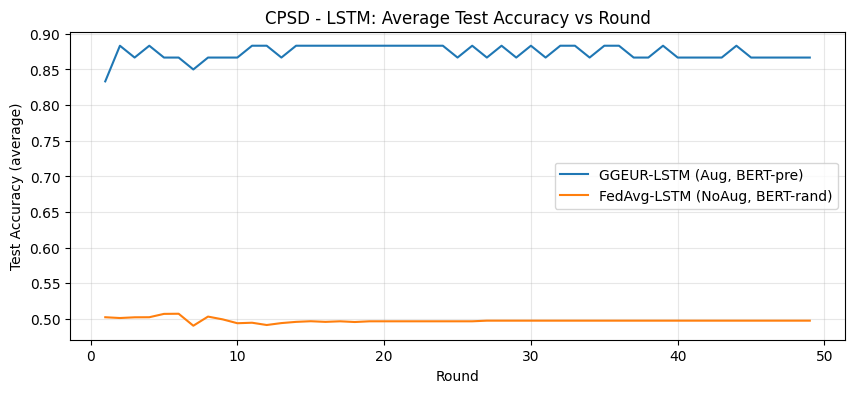

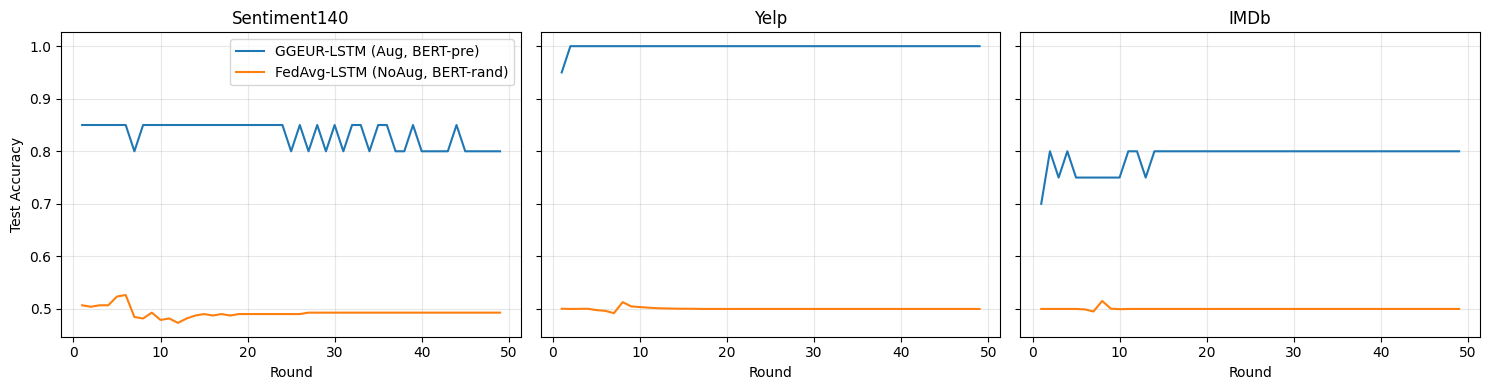

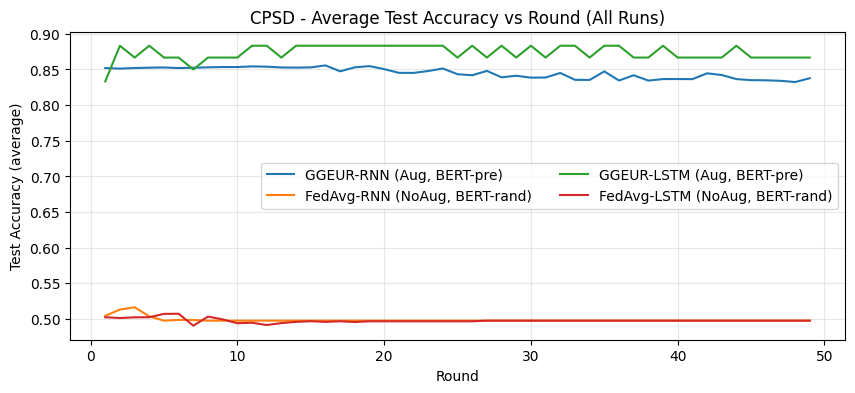

In [3]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_LSTM = Path(
    "exp/ggeur_rnn_sentiment/ggeur_cpsd_lstm/sub_exp_20260120172157/exp_print.log"
)
LOG_FEDAVG_LSTM = Path(
    "exp/fedavg_rnn_sentiment/fedavg_cpsd_lstm_no_augmentation/sub_exp_20260121113120/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "GGEUR-LSTM (Aug, BERT-pre)": LOG_GGEUR_LSTM,
    "FedAvg-LSTM (NoAug, BERT-rand)": LOG_FEDAVG_LSTM,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["Sentiment140", "Yelp", "IMDb"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()

# Optional: all-4 comparison on average accuracy
all_runs = {
    "GGEUR-RNN (Aug, BERT-pre)": Path(
        "exp/ggeur_rnn_sentiment/ggeur_cpsd_lstm/sub_exp_20260121144900/exp_print.log"
    ),
    "FedAvg-RNN (NoAug, BERT-rand)": Path(
        "exp/fedavg_rnn_sentiment/fedavg_cpsd_lstm_no_augmentation/sub_exp_20260126112305/exp_print.log"
    ),
    "GGEUR-LSTM (Aug, BERT-pre)": LOG_GGEUR_LSTM,
    "FedAvg-LSTM (NoAug, BERT-rand)": LOG_FEDAVG_LSTM,
}
plt.figure(figsize=(10, 4))
for name, p in all_runs.items():
    if not p.exists():
        continue
    d = parse_mlp_test_accuracy(p)
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - Average Test Accuracy vs Round (All Runs)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()


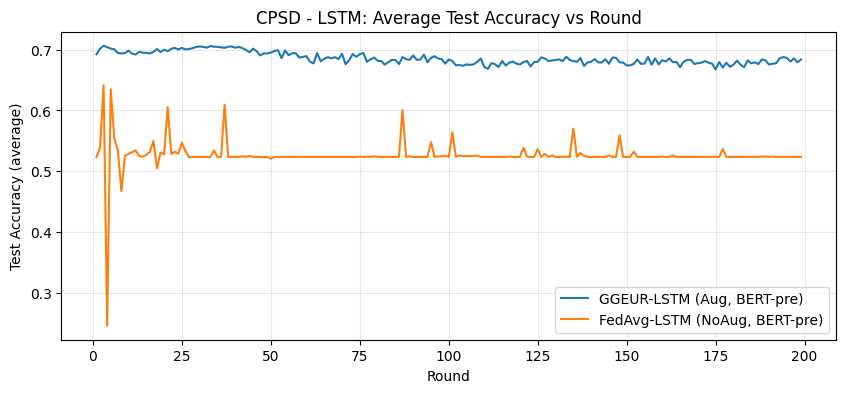

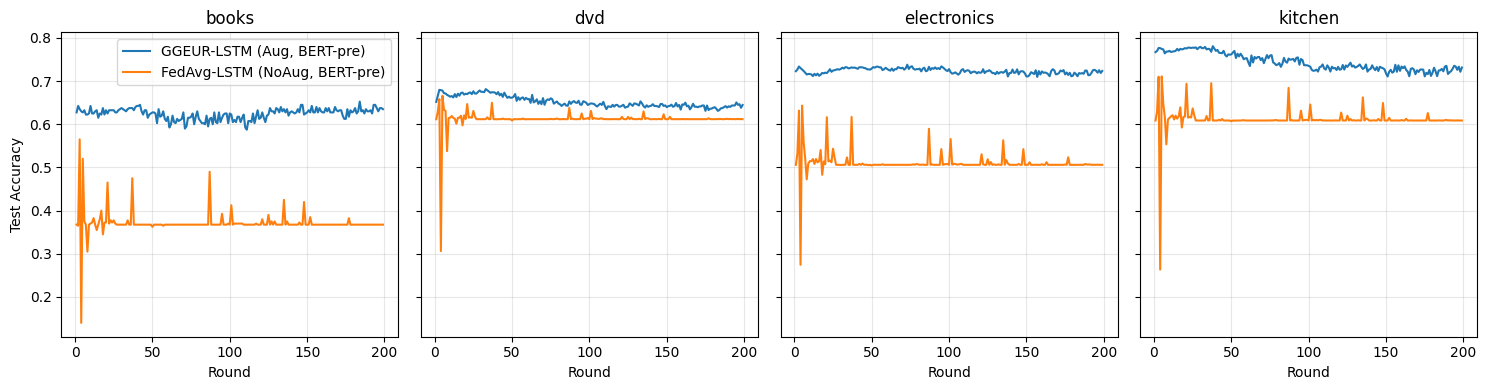

In [5]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/ggeur_rnn_sentiment/ggeur_mdsent_rating4_lstm/sub_exp_20260130111557/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260130111605/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "GGEUR-LSTM (Aug, BERT-pre)": LOG_GGEUR_RNN,
    "FedAvg-LSTM (NoAug, BERT-pre)": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


学习率0.1

exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260130111605/exp_print.log

exp\ggeur_rnn_sentiment\ggeur_mdsent_rating4_lstm\sub_exp_20260130151013\exp_print.log

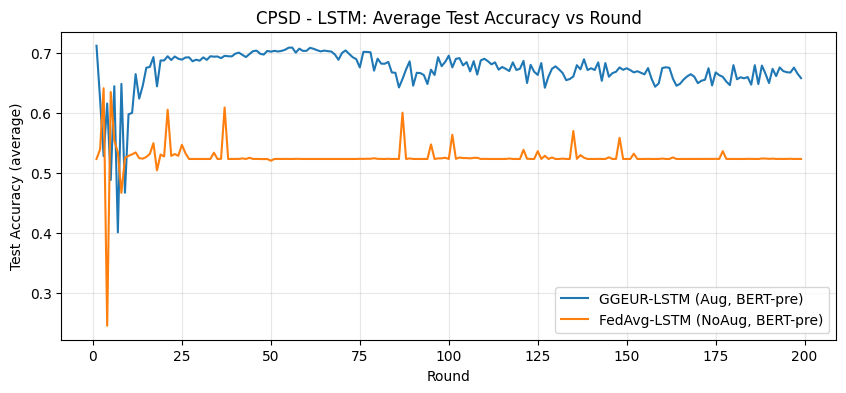

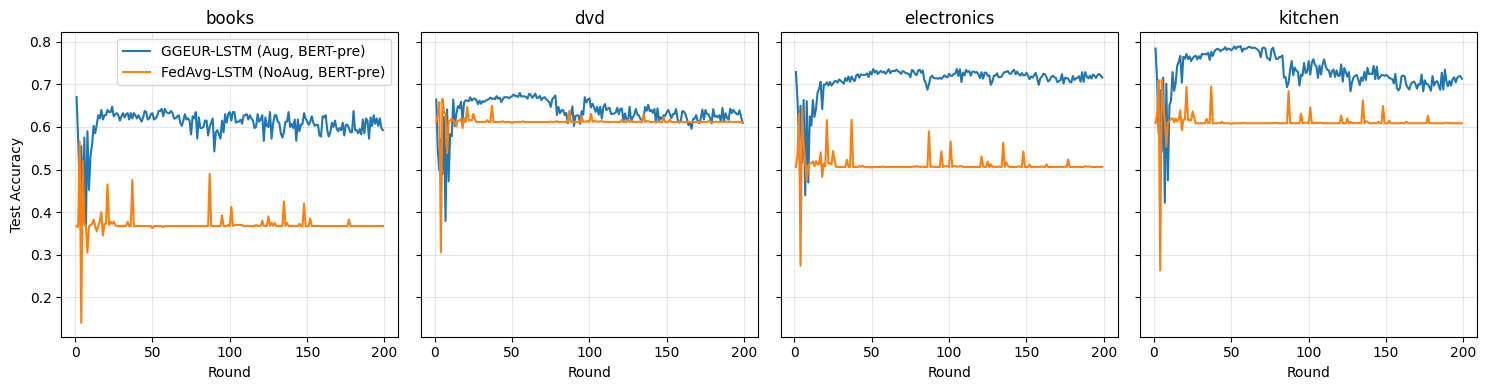

In [68]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp\ggeur_rnn_sentiment\ggeur_mdsent_rating4_lstm\sub_exp_20260130151013\exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260130111605/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "GGEUR-LSTM (Aug, BERT-pre)": LOG_GGEUR_RNN,
    "FedAvg-LSTM (NoAug, BERT-pre)": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


学习率：0.01

0.01

exp/ggeur_rnn_sentiment/ggeur_mdsent_rating4_lstm/sub_exp_20260130111557/exp_print.log

0.01

exp\fedavg_rnn_sentiment\fedavg_mdsent_rating4_lstm_no_augmentation\sub_exp_20260130164349\exp_print.log

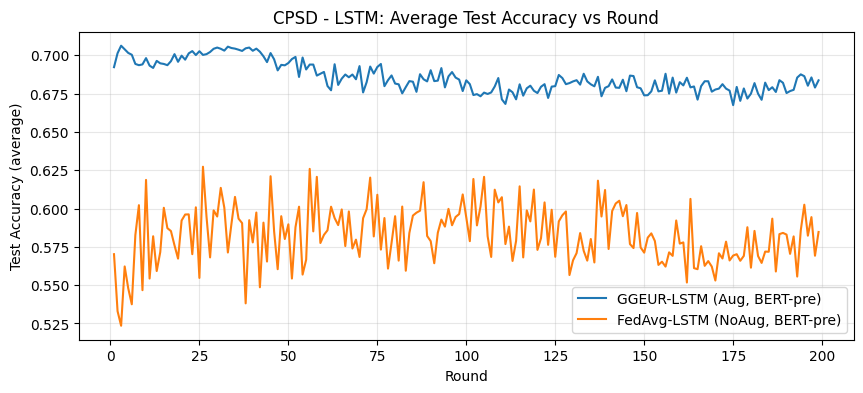

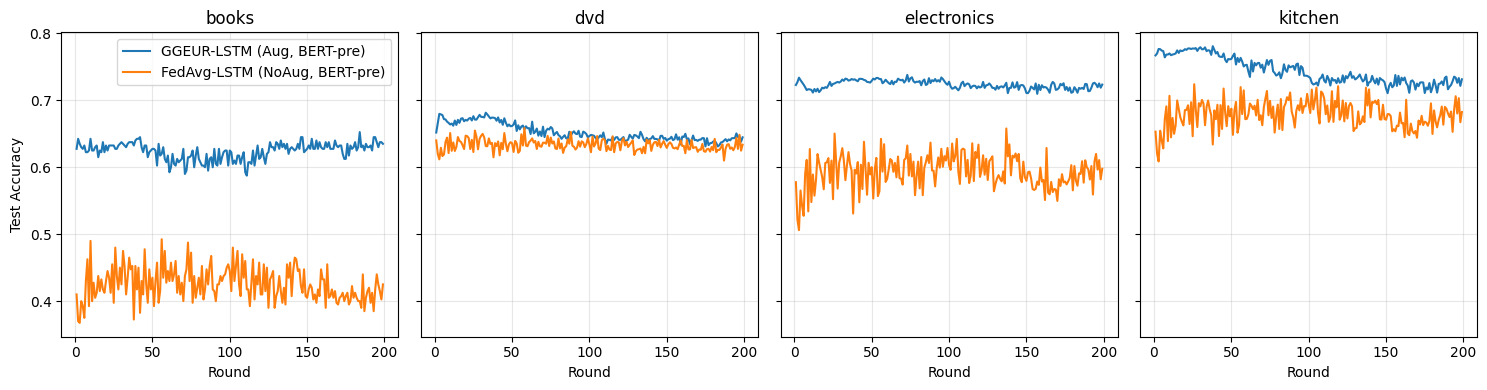

In [3]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/ggeur_rnn_sentiment/ggeur_mdsent_rating4_lstm/sub_exp_20260130111557/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260130164349/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "GGEUR-LSTM (Aug, BERT-pre)": LOG_GGEUR_RNN,
    "FedAvg-LSTM (NoAug, BERT-pre)": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


120客户端

exp\fedavg_rnn_sentiment\fedavg_mdsent_rating4_lstm_no_augmentation\sub_exp_20260203111615\exp_print.log

160客户端

exp\fedavg_rnn_sentiment\fedavg_mdsent_rating4_lstm_no_augmentation\sub_exp_20260203112019\exp_print.log

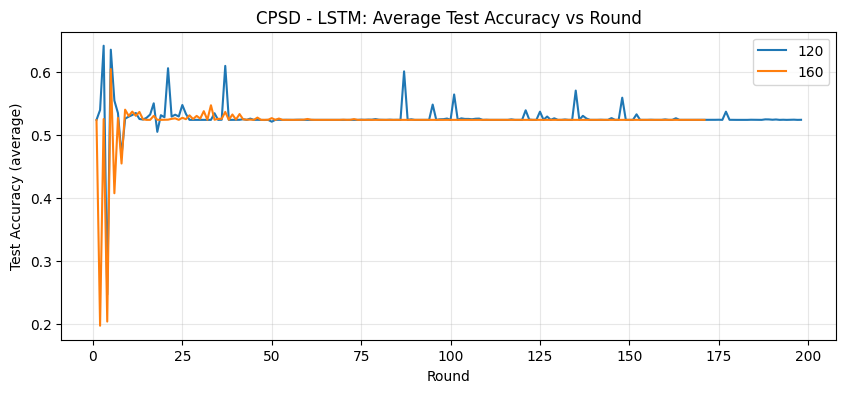

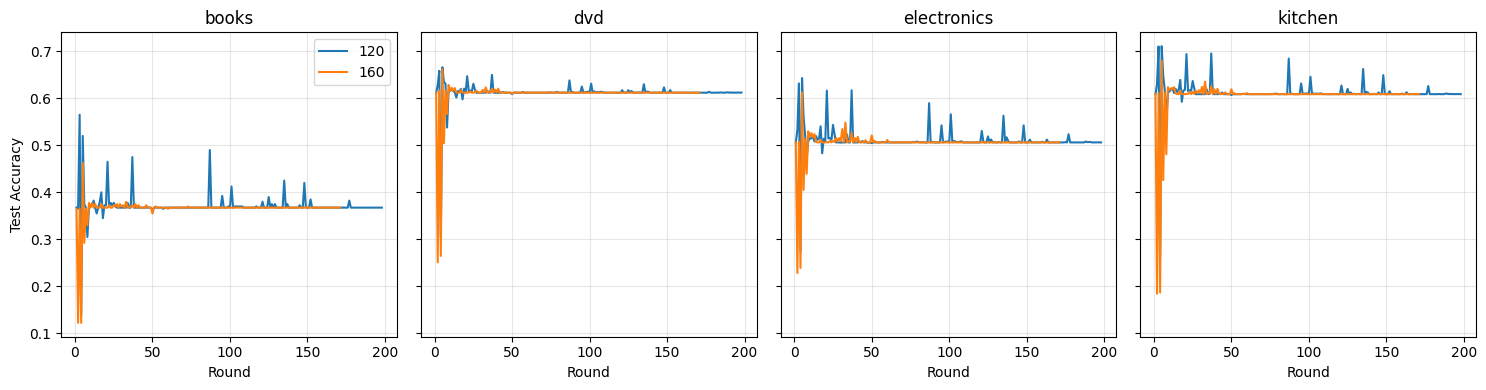

In [69]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260203111615/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260203112019/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "120": LOG_GGEUR_RNN,
    "160": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


alpha:0.005

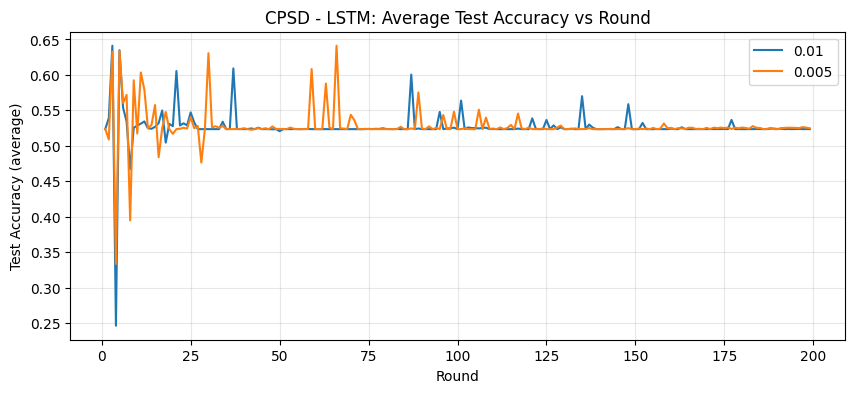

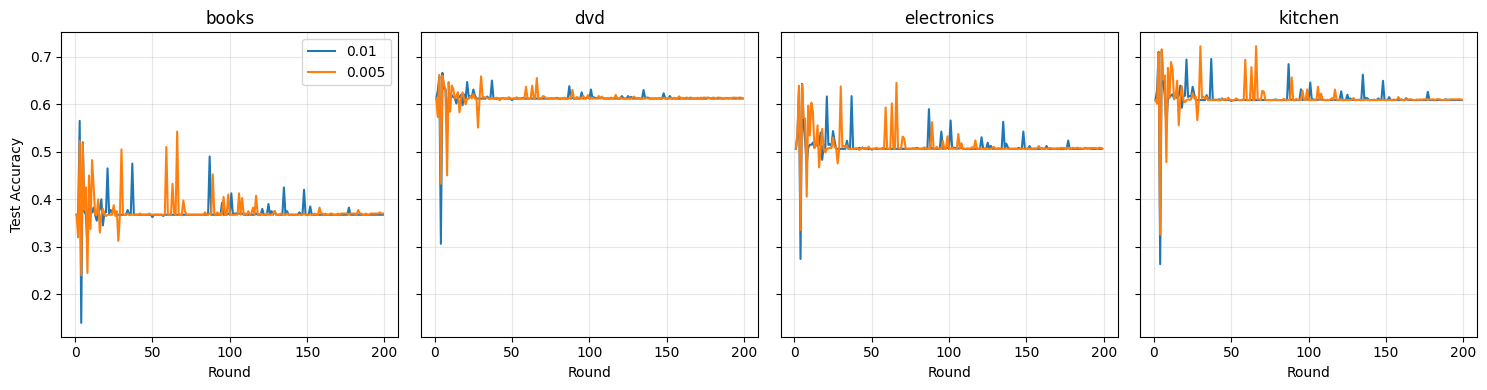

In [75]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260203111615/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260203113214/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "0.01": LOG_GGEUR_RNN,
    "0.005": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


学习率0.15

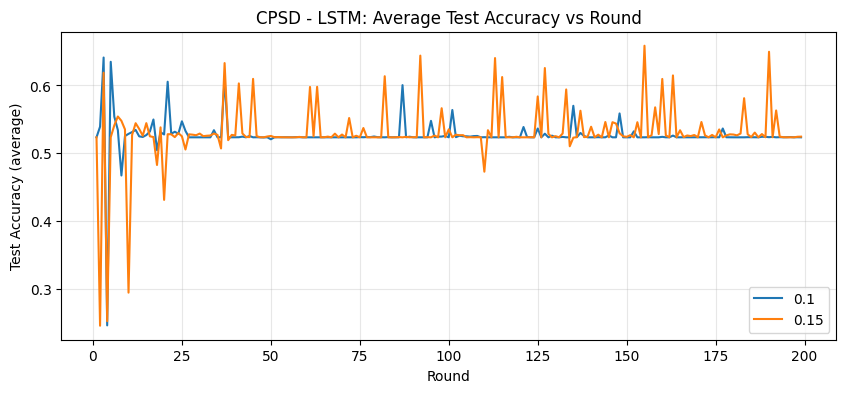

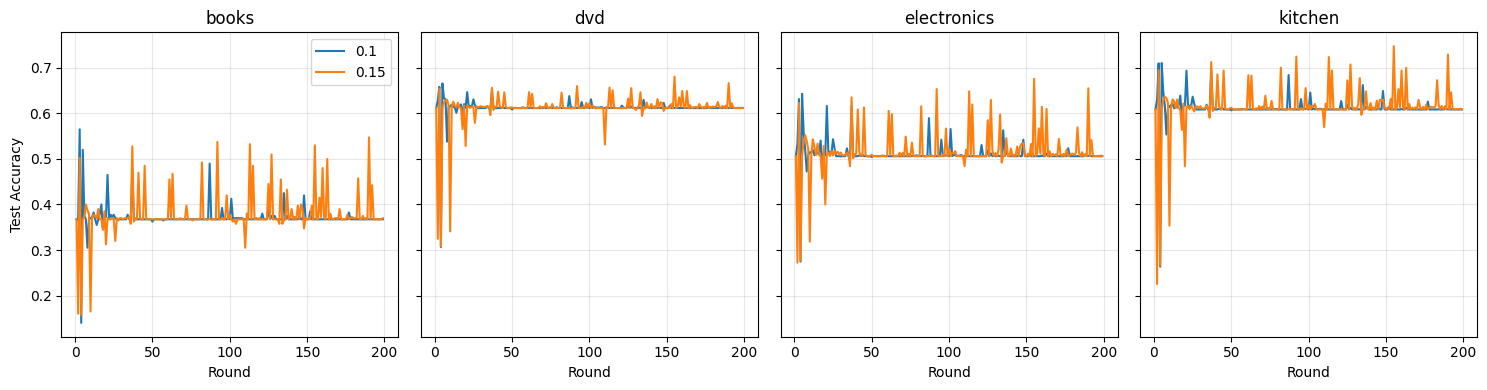

In [76]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260203111615/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260203114326/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "0.1": LOG_GGEUR_RNN,
    "0.15": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


local_update_steps: 5

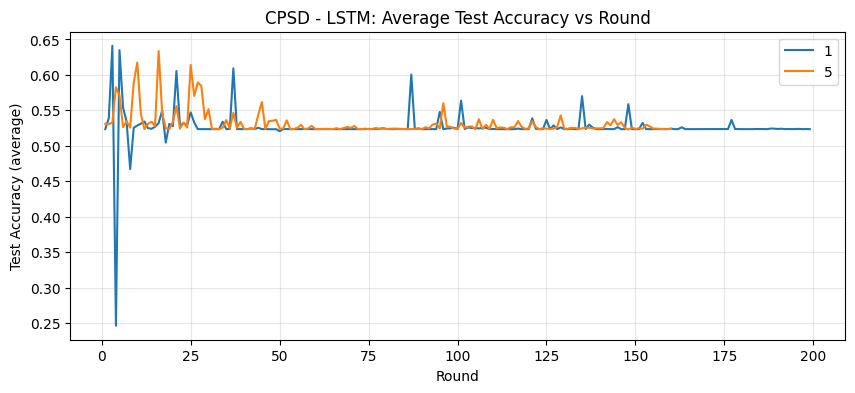

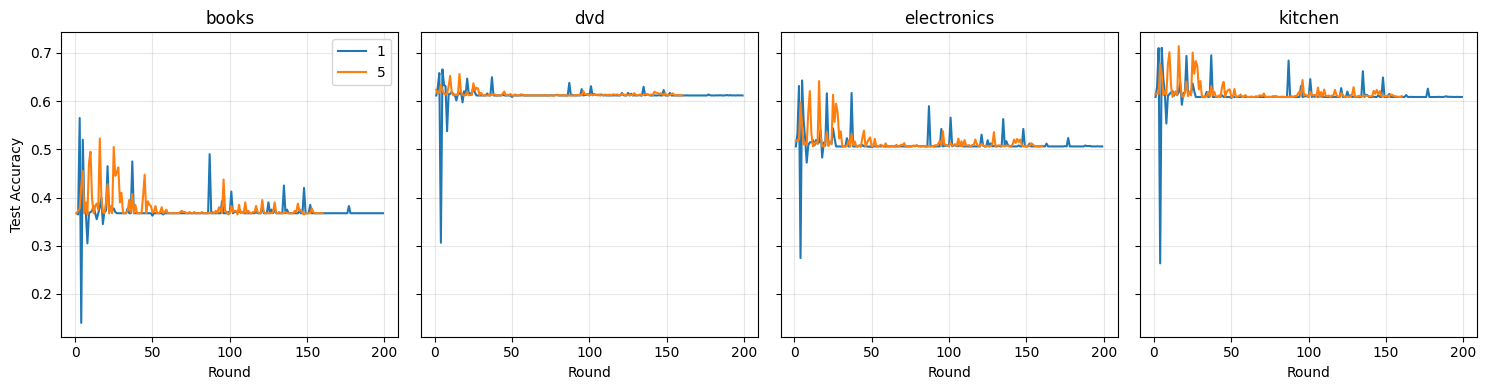

In [77]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260203111615/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260203115838/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "1": LOG_GGEUR_RNN,
    "5": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


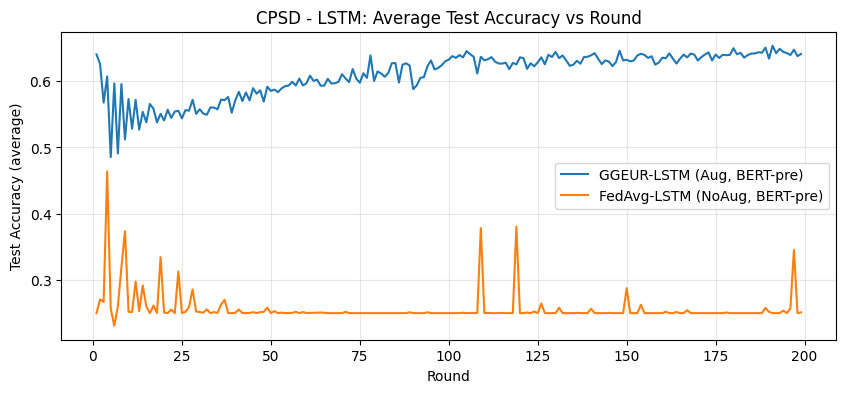

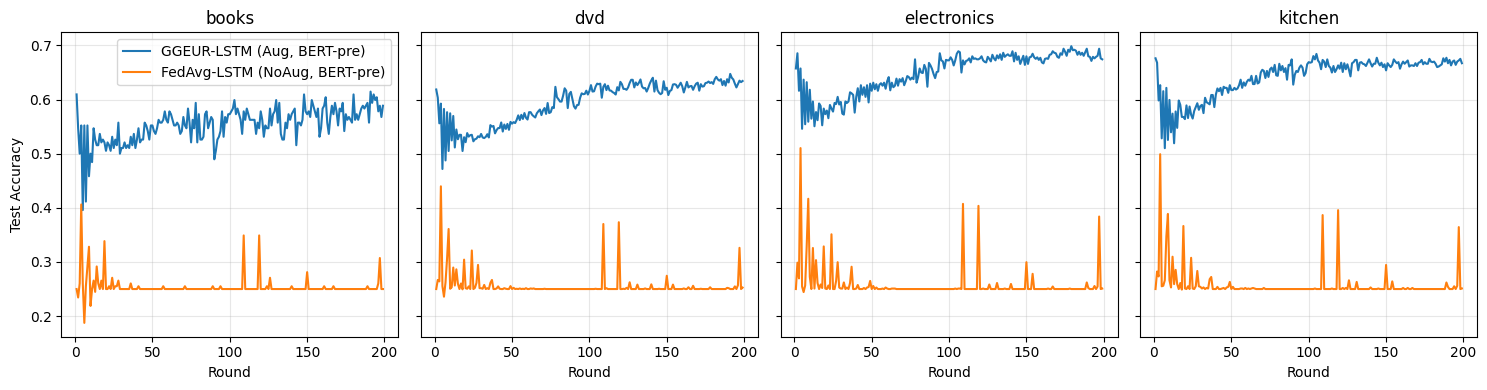

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/ggeur_rnn_sentiment/ggeur_mdsent_rating4_lstm/sub_exp_20260203160031/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260203160227/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "GGEUR-LSTM (Aug, BERT-pre)": LOG_GGEUR_RNN,
    "FedAvg-LSTM (NoAug, BERT-pre)": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


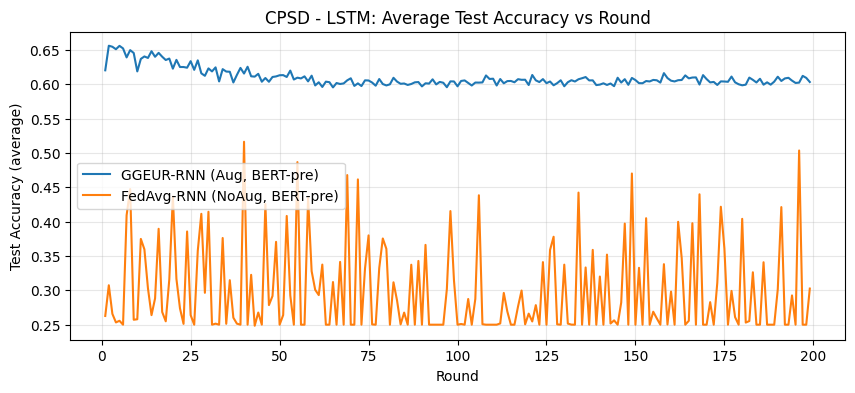

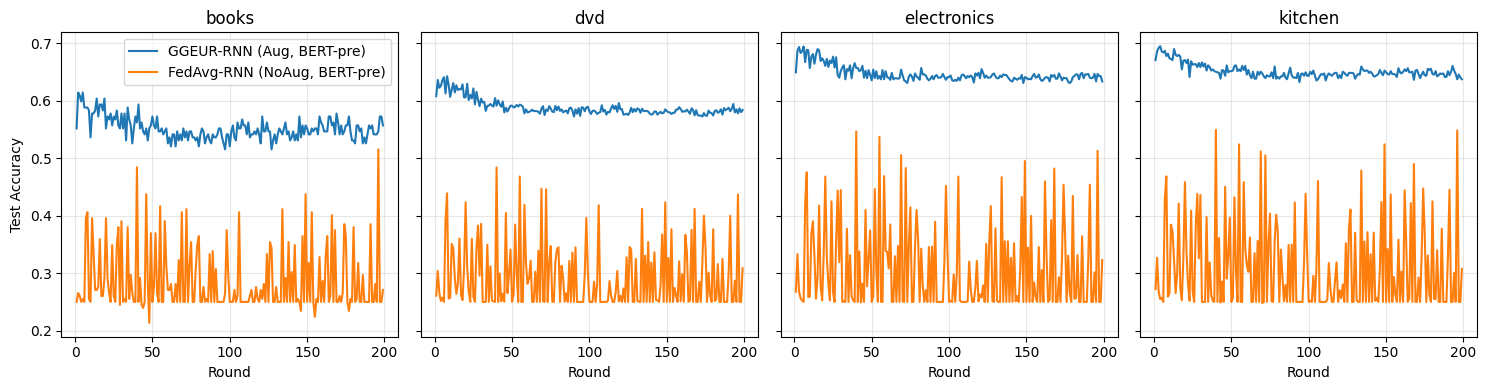

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/ggeur_rnn_sentiment/ggeur_mdsent_rating4_lstm/sub_exp_20260204105131/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260204105144/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "GGEUR-RNN (Aug, BERT-pre)": LOG_GGEUR_RNN,
    "FedAvg-RNN (NoAug, BERT-pre)": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


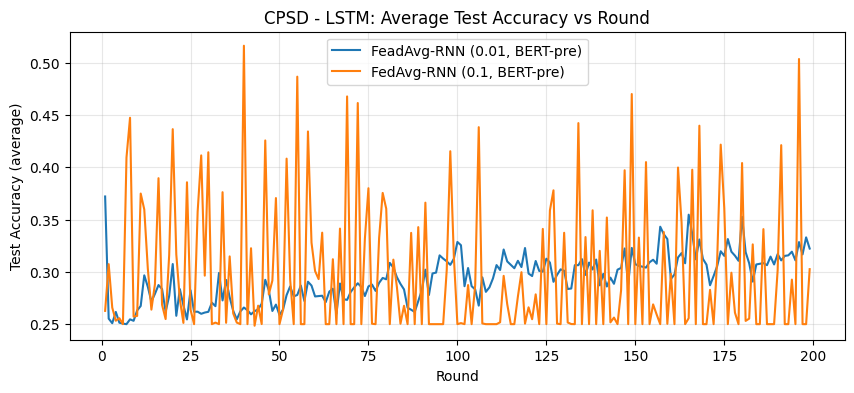

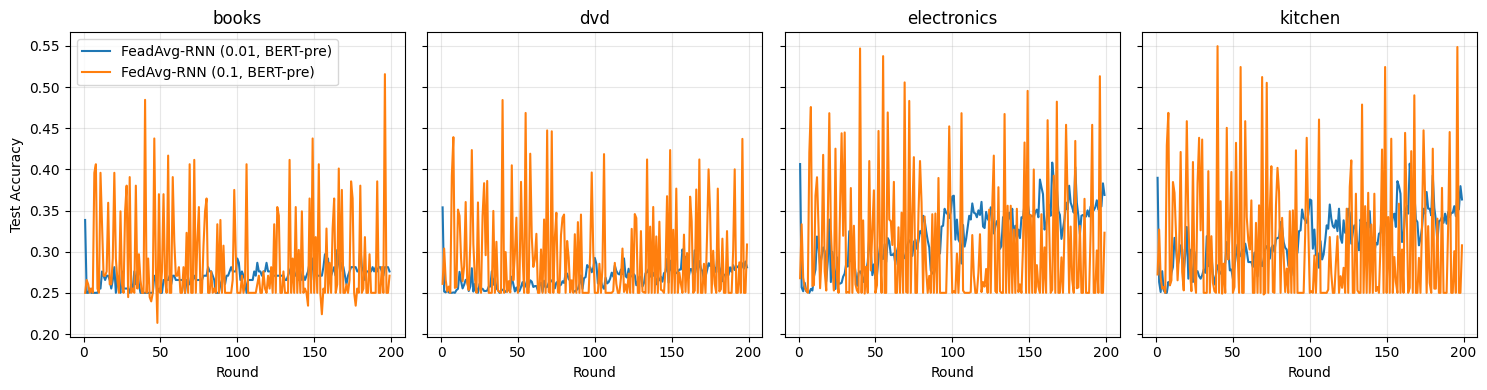

In [39]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_rnn_no_augmentation/sub_exp_20260204152710/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260204105144/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "FeadAvg-RNN (0.01, BERT-pre)": LOG_GGEUR_RNN,
    "FedAvg-RNN (0.1, BERT-pre)": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


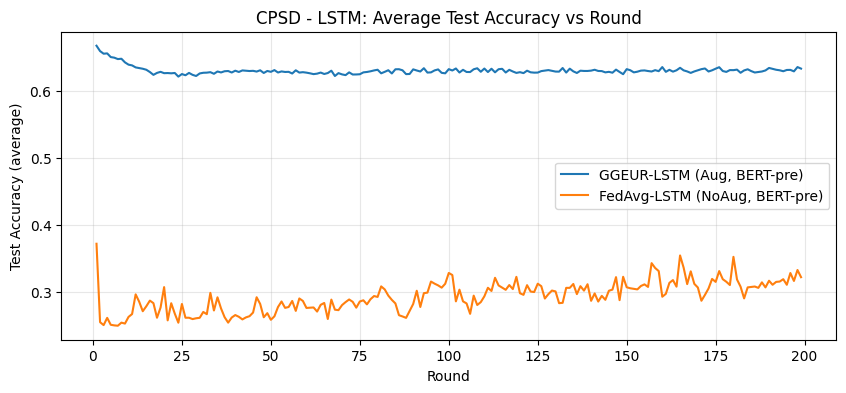

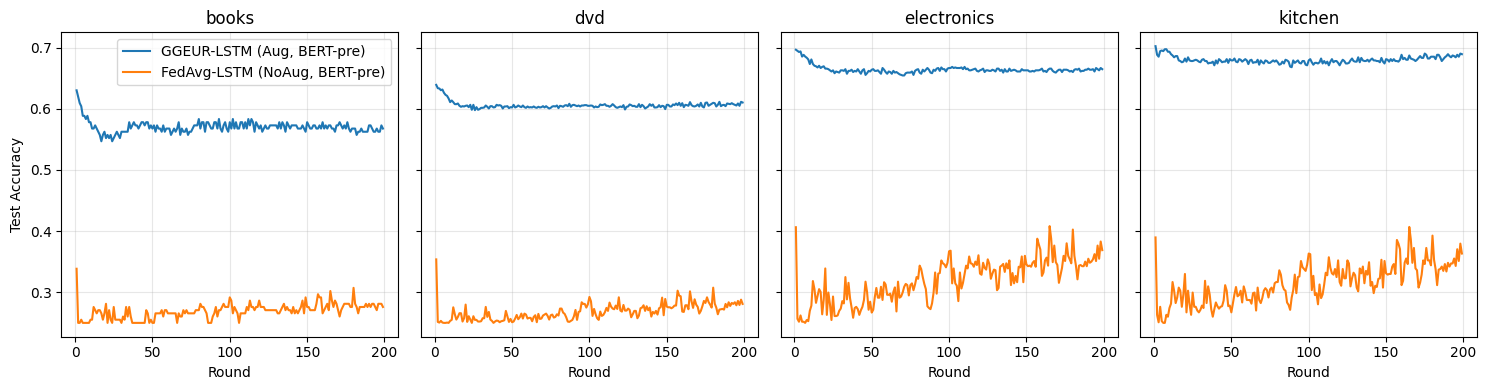

In [47]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/ggeur_rnn_sentiment/ggeur_mdsent_rating4_rnn/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_rnn_no_augmentation/sub_exp_20260204152710/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "GGEUR-LSTM (Aug, BERT-pre)": LOG_GGEUR_RNN,
    "FedAvg-LSTM (NoAug, BERT-pre)": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


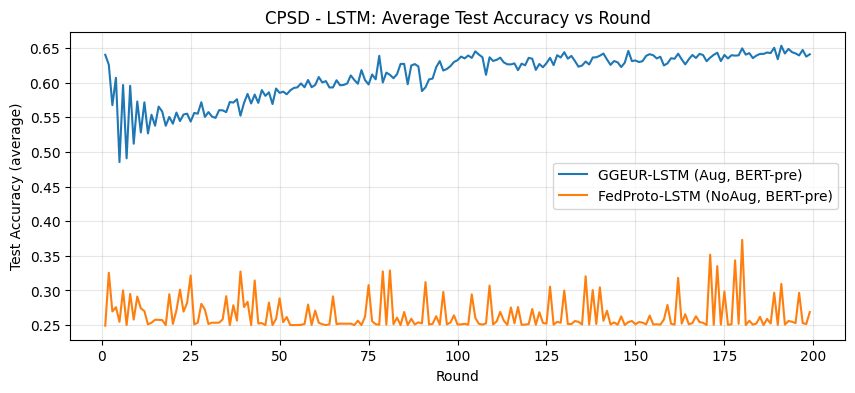

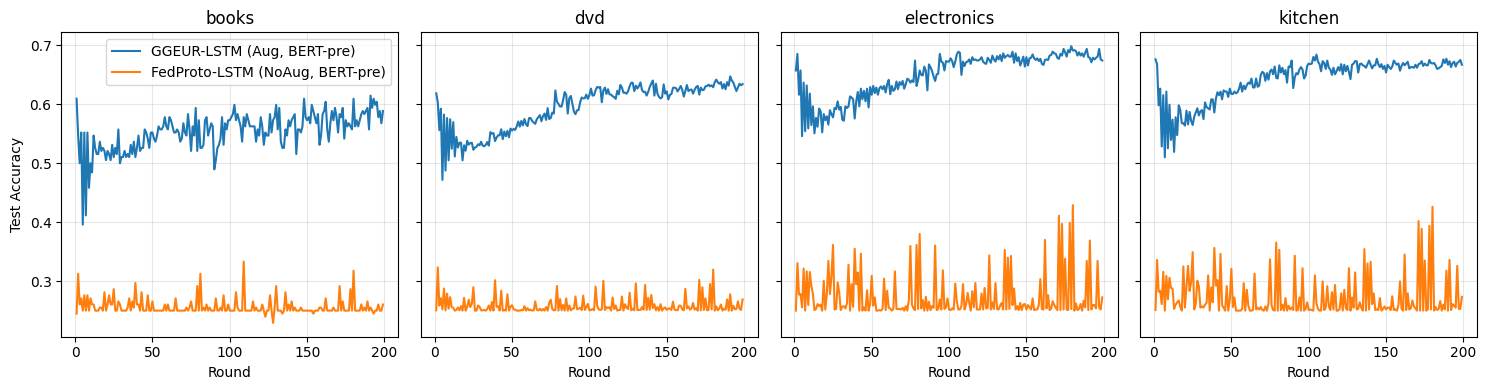

In [5]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/ggeur_rnn_sentiment/ggeur_mdsent_rating4_lstm/sub_exp_20260203160031/exp_print.log"
)
LOG_FEDPROTO_RNN = Path(
    "exp/fedproto_lstm_sentiment/fedproto_mdsent_rating4_lstm_no_augmentation/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "GGEUR-LSTM (Aug, BERT-pre)": LOG_GGEUR_RNN,
    "FedProto-LSTM (NoAug, BERT-pre)": LOG_FEDPROTO_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


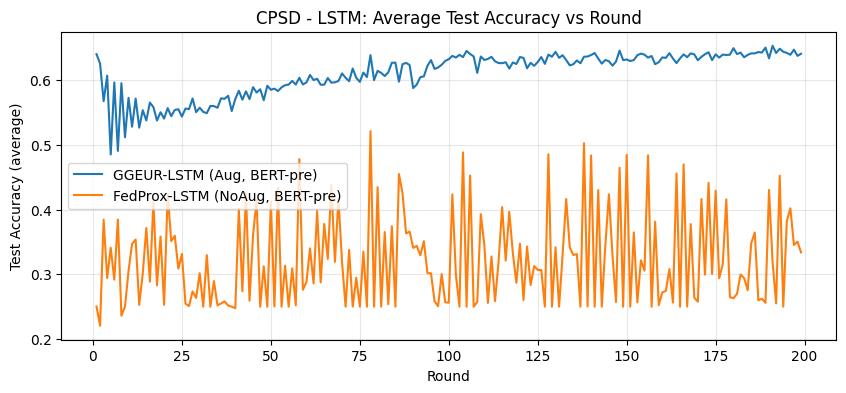

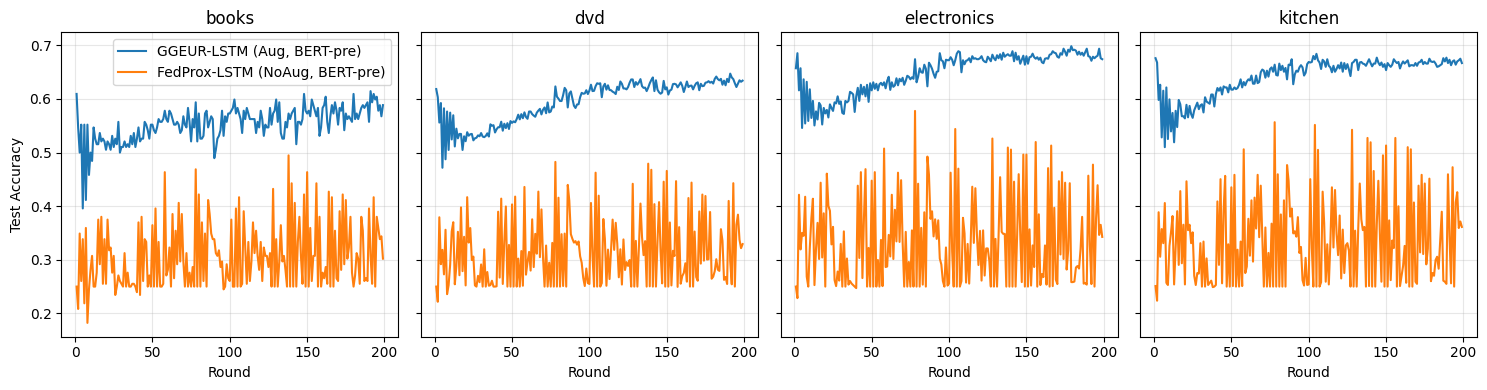

In [71]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/ggeur_rnn_sentiment/ggeur_mdsent_rating4_lstm/sub_exp_20260203160031/exp_print.log"
)
LOG_FEDPROX_RNN = Path(
    "exp/fedprox_lstm_sentiment/fedprox_mdsent_rating4_lstm_no_augmentation/sub_exp_20260205165349/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "GGEUR-LSTM (Aug, BERT-pre)": LOG_GGEUR_RNN,
    "FedProx-LSTM (NoAug, BERT-pre)": LOG_FEDPROX_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/ggeur_rnn_sentiment/ggeur_mdsent_rating4_rnn/exp_print.log"
)
LOG_FEDPROX_RNN = Path(
    "exp/fedproto_rnn_sentiment/fedproto_mdsent_rating4_rnn_no_augmentation/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "GGEUR-RNN (Aug, BERT-pre)": LOG_GGEUR_RNN,
    "FedProto-RNN (NoAug, BERT-pre)": LOG_FEDPROX_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


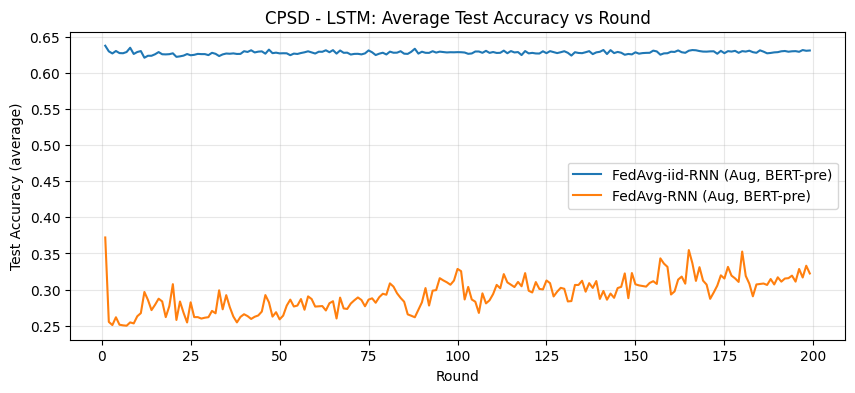

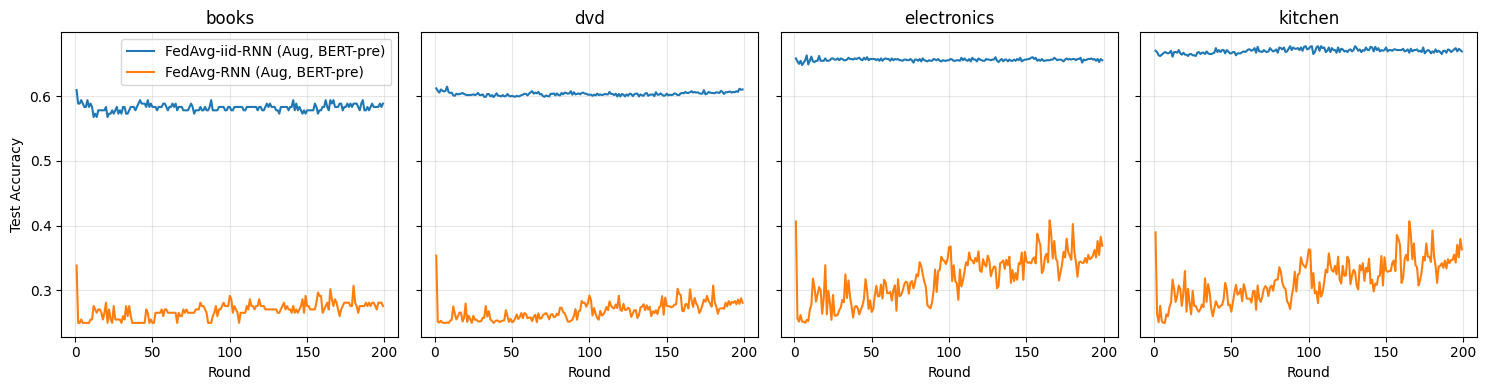

In [5]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/fedavg_rnn_sentiment_iid/fedavg_mdsent_rating4_rnn_iid_no_augmentation/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_rnn_no_augmentation/sub_exp_20260204152710/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "FedAvg-iid-RNN (Aug, BERT-pre)": LOG_GGEUR_RNN,
    "FedAvg-RNN (Aug, BERT-pre)": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()


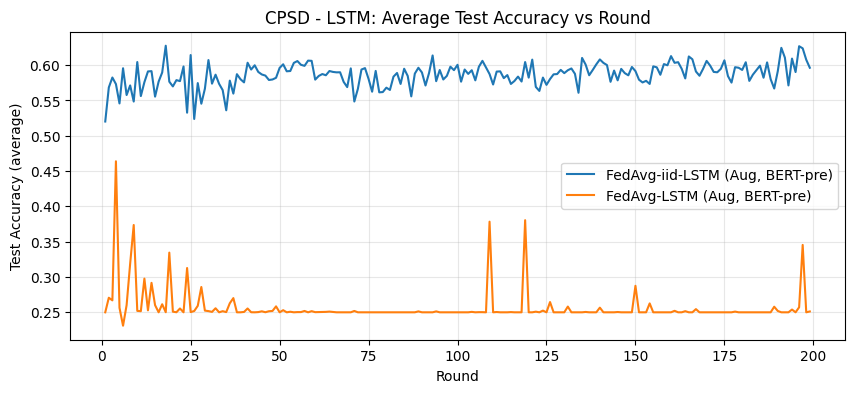

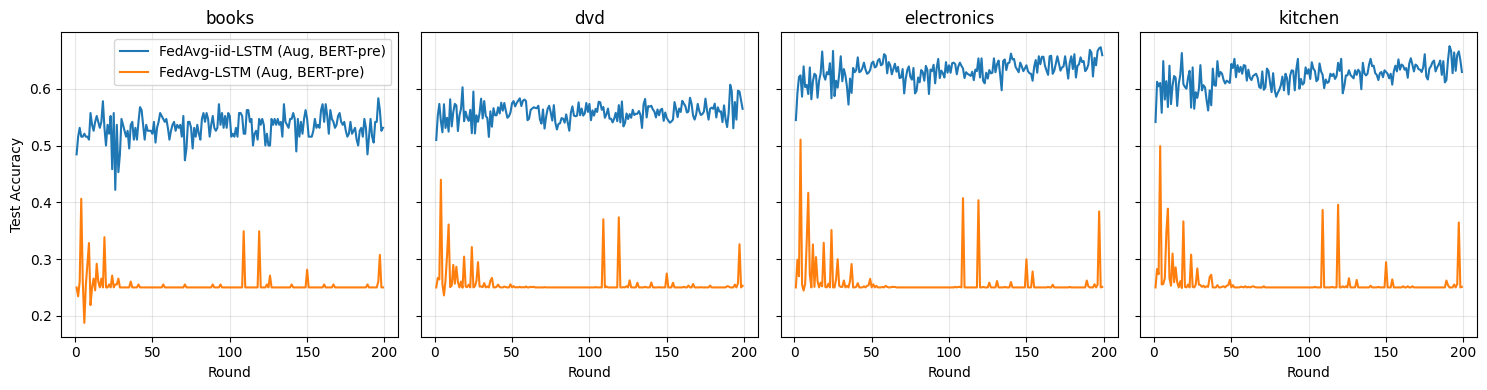

In [4]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

LOG_GGEUR_RNN = Path(
    "exp/fedavg_lstm_sentiment_iid/fedavg_mdsent_rating4_lstm_iid_no_augmentation/exp_print.log"
)
LOG_FEDAVG_RNN = Path(
    "exp/fedavg_rnn_sentiment/fedavg_mdsent_rating4_lstm_no_augmentation/sub_exp_20260203160227/exp_print.log"
)


def parse_mlp_test_accuracy(log_path: Path):
    pattern = re.compile(r"Server: Round (\d+) MLP Test Accuracy - (.*)$")
    per_round = {}

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue

            round_idx = int(m.group(1))
            metrics_str = m.group(2).strip()
            row = {"round": round_idx}

            for chunk in metrics_str.split(","):
                if ":" not in chunk:
                    continue
                key, value = chunk.split(":", 1)
                key = key.strip()
                value = value.strip()
                try:
                    row[key] = float(value)
                except ValueError:
                    continue

            per_round[round_idx] = row

    rounds = sorted(per_round)
    if not rounds:
        raise ValueError(
            f"No 'Server: Round ... MLP Test Accuracy' lines found in {log_path}"
        )

    keys = sorted({k for r in rounds for k in per_round[r].keys()} - {"round"})
    data = {"round": rounds}
    for k in keys:
        data[k] = [per_round[r].get(k) for r in rounds]
    return data


runs = {
    "FedAvg-iid-LSTM (Aug, BERT-pre)": LOG_GGEUR_RNN,
    "FedAvg-LSTM (Aug, BERT-pre)": LOG_FEDAVG_RNN,
}

parsed = {}
for name, p in runs.items():
    if not p.exists():
        raise FileNotFoundError(p)
    parsed[name] = parse_mlp_test_accuracy(p)

# Average accuracy
plt.figure(figsize=(10, 4))
for name, d in parsed.items():
    plt.plot(d["round"], d["average"], label=name)
plt.xlabel("Round")
plt.ylabel("Test Accuracy (average)")
plt.title("CPSD - LSTM: Average Test Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Per-domain accuracy
domains = ["books", "dvd", "electronics", "kitchen"]
fig, axes = plt.subplots(1, len(domains), figsize=(15, 4), sharex=True, sharey=True)
for ax, domain in zip(axes, domains):
    for name, d in parsed.items():
        if domain in d:
            ax.plot(d["round"], d[domain], label=name)
    ax.set_title(domain)
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()
